# 01 - Engagement Analysis (English-Only Rerun)

Reruns Method #5 (`code/05_engagement_analysis.ipynb`) on `trends_combined_english.csv`
(built in Task 1) instead of the original all-language per-trend CSVs. This produces the
accurate English-only engagement ranking for the project write-up.

Note: this rerun no longer determines the regression baseline for Task 5 (sourdough is fixed
as the baseline for both models regardless of this task's outcome), but is still needed for
accurate reporting, since the all-language ranking is known to shift once restricted to
English-only.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, mannwhitneyu, f_oneway
from itertools import combinations
import matplotlib.pyplot as plt

## Step 1: Load `trends_combined_english.csv`, confirm shape matches Task 1's output

In [2]:
combined = pd.read_csv("../output/cleaned_data/trends_combined_english.csv")
print(combined.shape)

(126410, 23)


## Step 2: Repeat the same analysis as `05_engagement_analysis.ipynb`, on this English-only file

### Distribution shape check

In [3]:
engagement_cols = ["statistics.like_count", "statistics.comment_count"]

print("Likes summary by trend:")
print(combined.groupby("trend")["statistics.like_count"].describe()[["mean", "50%", "max"]])
print()
print("Comments summary by trend:")
print(combined.groupby("trend")["statistics.comment_count"].describe()[["mean", "50%", "max"]])

Likes summary by trend:
                       mean    50%       max
trend                                       
baked_oats      1217.157025  420.0   18403.0
banana_bread     853.529546  197.0  216202.0
dalgona_coffee  1638.860289  244.0  743149.0
feta_pasta      1803.519868  208.0  180929.0
sourdough        758.269591  223.0  456187.0

Comments summary by trend:
                     mean   50%      max
trend                                   
baked_oats      64.512397  37.0    400.0
banana_bread    39.986778  11.0  13165.0
dalgona_coffee  43.032858  10.0   9824.0
feta_pasta      46.867550  11.0   2866.0
sourdough       26.431906   8.0   7937.0


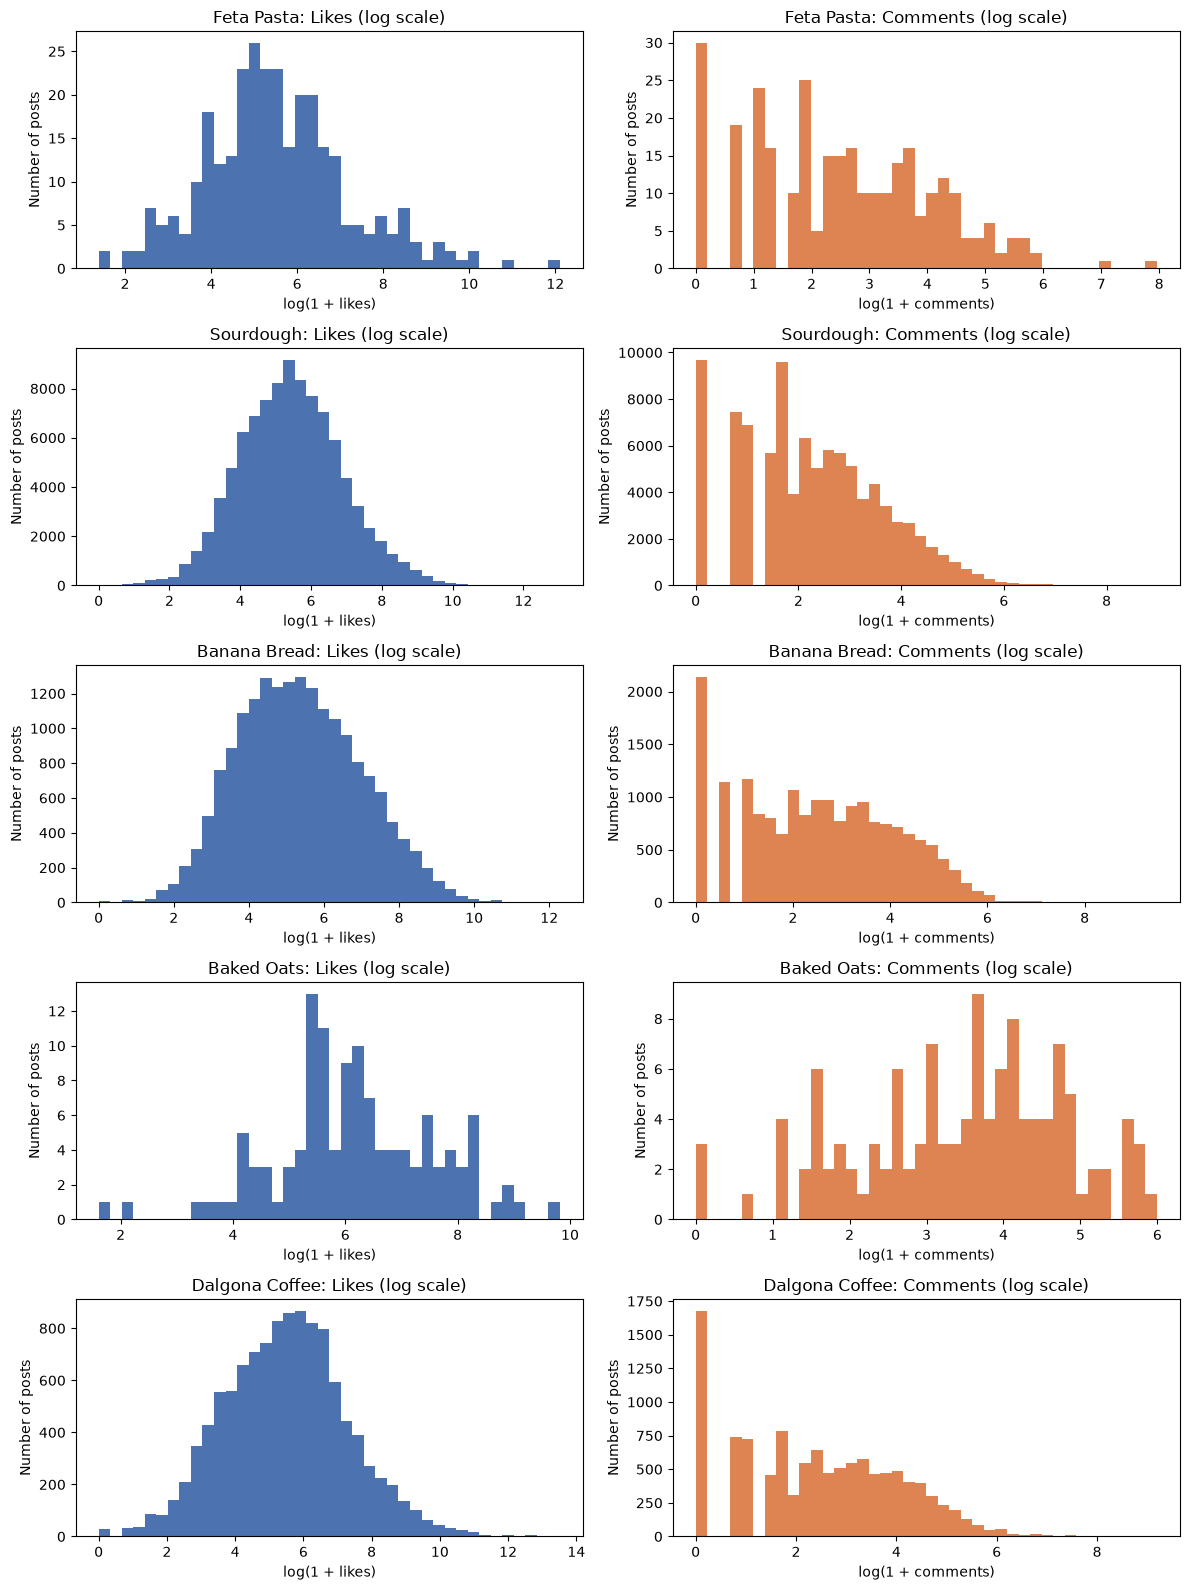

In [4]:
# --- Distribution histograms: likes and comments, per trend (log1p scale) ---
fig, axes = plt.subplots(5, 2, figsize=(12, 16))

trends_order = ["feta_pasta", "sourdough", "banana_bread", "baked_oats", "dalgona_coffee"]

for i, trend in enumerate(trends_order):
    subset = combined[combined["trend"] == trend]

    axes[i, 0].hist(np.log1p(subset["statistics.like_count"]), bins=40, color="#4c72b0")
    axes[i, 0].set_title(f"{trend.replace('_', ' ').title()}: Likes (log scale)")
    axes[i, 0].set_xlabel("log(1 + likes)")
    axes[i, 0].set_ylabel("Number of posts")

    axes[i, 1].hist(np.log1p(subset["statistics.comment_count"]), bins=40, color="#dd8452")
    axes[i, 1].set_title(f"{trend.replace('_', ' ').title()}: Comments (log scale)")
    axes[i, 1].set_xlabel("log(1 + comments)")
    axes[i, 1].set_ylabel("Number of posts")

plt.tight_layout()
plt.savefig("../output/engagement/viz_english_engagement_distributions.png", dpi=150)
plt.show()

### Primary test: Kruskal-Wallis

In [5]:
def run_kruskal(metric_col, metric_name):
    groups = [g[metric_col].values for _, g in combined.groupby("trend")]
    stat, p = kruskal(*groups)
    print(f"{metric_name}: H = {stat:.2f}, p-value = {p:.4f}")
    return stat, p

print("Kruskal-Wallis results (is there a difference somewhere among the 5 trends?):\n")
likes_stat, likes_p = run_kruskal("statistics.like_count", "Likes")
comments_stat, comments_p = run_kruskal("statistics.comment_count", "Comments")

Kruskal-Wallis results (is there a difference somewhere among the 5 trends?):

Likes: H = 103.88, p-value = 0.0000
Comments: H = 597.98, p-value = 0.0000


### Secondary/robustness check: one-way ANOVA on log-transformed data

In [6]:
combined["log_likes"] = np.log1p(combined["statistics.like_count"])
combined["log_comments"] = np.log1p(combined["statistics.comment_count"])

def run_anova(metric_col, metric_name):
    groups = [g[metric_col].values for _, g in combined.groupby("trend")]
    stat, p = f_oneway(*groups)
    print(f"{metric_name} (log-transformed): F = {stat:.2f}, p-value = {p:.4f}")
    return stat, p

print("One-way ANOVA results on log-transformed data:\n")
run_anova("log_likes", "Likes")
run_anova("log_comments", "Comments")

One-way ANOVA results on log-transformed data:



Likes (log-transformed): F = 20.76, p-value = 0.0000
Comments (log-transformed): F = 175.96, p-value = 0.0000


(np.float64(175.963978506535), np.float64(1.345445154316977e-150))

### Follow-up: pairwise comparisons (Mann-Whitney U)

In [7]:
def pairwise_comparison_table(metric_col, metric_name, alpha=0.05):
    rows = []
    trends = combined["trend"].unique()
    for t1, t2 in combinations(trends, 2):
        g1 = combined[combined["trend"] == t1][metric_col]
        g2 = combined[combined["trend"] == t2][metric_col]
        stat, p = mannwhitneyu(g1, g2)
        median1, median2 = g1.median(), g2.median()
        higher = t1 if median1 > median2 else t2
        rows.append({
            "Trend 1": t1,
            "Median 1": median1,
            "Trend 2": t2,
            "Median 2": median2,
            "P-value": round(p, 4),
            "Significant (p<0.05)": p < alpha,
            "Higher Median": higher,
        })
    return pd.DataFrame(rows).sort_values("P-value").reset_index(drop=True)

def highlight_significant(row):
    color = "background-color: #c6efce" if row["Significant (p<0.05)"] else "background-color: #ffc7ce"
    return [color] * len(row)

likes_table = pairwise_comparison_table("statistics.like_count", "Likes")
comments_table = pairwise_comparison_table("statistics.comment_count", "Comments")

print("LIKES: Pairwise comparisons")
display(likes_table.style.apply(highlight_significant, axis=1))

print("\nCOMMENTS: Pairwise comparisons")
display(comments_table.style.apply(highlight_significant, axis=1))

LIKES: Pairwise comparisons


,Trend 1,Median 1,Trend 2,Median 2,P-value,Significant (p<0.05),Higher Median
0,feta_pasta,208.000000,baked_oats,420.000000,0.000000,True,baked_oats
1,banana_bread,197.000000,baked_oats,420.000000,0.000000,True,baked_oats
2,sourdough,223.000000,baked_oats,420.000000,0.000000,True,baked_oats
3,sourdough,223.000000,banana_bread,197.000000,0.000000,True,sourdough
4,baked_oats,420.000000,dalgona_coffee,244.000000,0.000000,True,baked_oats
5,banana_bread,197.000000,dalgona_coffee,244.000000,0.000000,True,dalgona_coffee
6,sourdough,223.000000,dalgona_coffee,244.000000,0.008400,True,dalgona_coffee
7,feta_pasta,208.000000,banana_bread,197.000000,0.134100,False,feta_pasta
8,feta_pasta,208.000000,sourdough,223.000000,0.712800,False,sourdough
9,feta_pasta,208.000000,dalgona_coffee,244.000000,0.961500,False,dalgona_coffee



COMMENTS: Pairwise comparisons


,Trend 1,Median 1,Trend 2,Median 2,P-value,Significant (p<0.05),Higher Median
0,feta_pasta,11.000000,baked_oats,37.000000,0.000000,True,baked_oats
1,sourdough,8.000000,dalgona_coffee,10.000000,0.000000,True,dalgona_coffee
2,sourdough,8.000000,baked_oats,37.000000,0.000000,True,baked_oats
3,sourdough,8.000000,banana_bread,11.000000,0.000000,True,banana_bread
4,banana_bread,11.000000,baked_oats,37.000000,0.000000,True,baked_oats
5,banana_bread,11.000000,dalgona_coffee,10.000000,0.000000,True,banana_bread
6,baked_oats,37.000000,dalgona_coffee,10.000000,0.000000,True,baked_oats
7,feta_pasta,11.000000,sourdough,8.000000,0.005000,True,feta_pasta
8,feta_pasta,11.000000,dalgona_coffee,10.000000,0.450500,False,feta_pasta
9,feta_pasta,11.000000,banana_bread,11.000000,0.870000,False,banana_bread


## Step 3: Trend with lowest median likes (English-only)

No longer sets the regression baseline (sourdough is fixed for that, see Task 5), but useful
context for accurate write-up reporting.

In [8]:
median_by_trend = combined.groupby("trend")["statistics.like_count"].median().sort_values()
print("Trend ranking, lowest to highest median likes (English-only):")
print(median_by_trend)

median_comments_by_trend = combined.groupby("trend")["statistics.comment_count"].median().sort_values()
print("\nTrend ranking, lowest to highest median comments (English-only):")
print(median_comments_by_trend)

Trend ranking, lowest to highest median likes (English-only):
trend
banana_bread      197.0
feta_pasta        208.0
sourdough         223.0
dalgona_coffee    244.0
baked_oats        420.0
Name: statistics.like_count, dtype: float64

Trend ranking, lowest to highest median comments (English-only):
trend
sourdough          8.0
dalgona_coffee    10.0
feta_pasta        11.0
banana_bread      11.0
baked_oats        37.0
Name: statistics.comment_count, dtype: float64


## Step 4: Comparison against the original all-language results

Original all-language results (`MASTER_PROJECT_REFERENCE.md` Section 10):

| Trend | N | Median likes | Median comments |
|---|---|---|---|
| baked_oats | 125 | 430 | 37 |
| feta_pasta | 328 | 240 | 11 |
| dalgona_coffee | 26,312 | 217 | 7 |
| banana_bread | 27,037 | 229 | 12 |
| sourdough | 136,366 | 212 | 8 |

Original confirmed order (likes): baked_oats > banana_bread > dalgona_coffee > sourdough
(feta_pasta unplaceable, tied with the middle three).

Original confirmed order (comments): baked_oats > (banana_bread ≈ feta_pasta) > sourdough >
dalgona_coffee.

Print English-only sample sizes and medians side by side with the above for direct comparison.

In [9]:
n_by_trend = combined.groupby("trend").size()
summary = pd.DataFrame({
    "N (English-only)": n_by_trend,
    "Median likes (English-only)": combined.groupby("trend")["statistics.like_count"].median(),
    "Median comments (English-only)": combined.groupby("trend")["statistics.comment_count"].median(),
})
summary = summary.sort_values("Median likes (English-only)")
print(summary)

                N (English-only)  Median likes (English-only)  \
trend                                                           
banana_bread               18378                        197.0   
feta_pasta                   302                        208.0   
sourdough                  96257                        223.0   
dalgona_coffee             11352                        244.0   
baked_oats                   121                        420.0   

                Median comments (English-only)  
trend                                           
banana_bread                              11.0  
feta_pasta                                11.0  
sourdough                                  8.0  
dalgona_coffee                            10.0  
baked_oats                                37.0  


## Notes

- This compares median/average engagement per post, not total engagement per trend.
- Kruskal-Wallis is the primary result to report, given the confirmed right-skew in the data;
  the log-transformed ANOVA is a secondary check for robustness, not a separate finding.
- A significant overall test only says a difference exists *somewhere* among the five trends;
  the pairwise Mann-Whitney U results identify which specific pairs differ.
- `views` could not be analyzed, missing for 100% of posts in this dataset.
- This rerun no longer determines the Task 5 regression baseline (sourdough is fixed for both
  models regardless), but is reported here for accurate write-up context.